# Non-interacting bandstructure

taking the 2 orbital model with the |x,up>, |y,down> state and adding a third dimension

In [1]:
import numpy as np
from numpy import pi,cos,sin,exp
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
import itertools
colors = ['C0','C1','C2','C3','C4','C5','C6','C7','C8','C0','C1','C2','C3','C4','C5','C6','C7','C8']



from blochK.observable import eigs_H, exp_value_O, isDegenerateIn, conductivity
from blochK.plotting import plot_FS, plot_bandstruc
from blochK.methods_basic import sample_BZ


def dict2listofdict(d):
    """Transforms a dictionary with lists to a list of dictionaries taking all possible values"""
    lod = []
    for entry in itertools.product(*[d[i] for i in d]):
        kwargs = {param: value for param, value in zip(d, entry)}
        lod.append(kwargs.copy())
    return lod

In [4]:
from alter_surf.hamiltonian_2orbital import H_2orb_3D, Spin_operator, points_BZ

def projector2layer(layer,len_z=2):
    """Projector operator onto specific layer."""
    proj = np.zeros(len_z)
    proj[layer] = 1
    return proj



/Users/valentin/Documents/1_Promotion/Altermagnetism/Surface/alter_surf/src/blochK/plotting.py:94: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. In future versions, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = copy.copy(mpl.cm.get_cmap("bwr"))
  cmap.set_under(color='black')
/Users/valentin/Documents/1_Promotion/Altermagnetism/Surface/alter_surf/src/blochK/plotting.py:95: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. In future versions, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = copy.copy(mpl.cm.get_cmap("bwr"))
  cmap.set_over(color='gray')
/Users/valentin/Documents/1_Promotion/Altermagnetism/Surface/alter_surf/src/blochK/plotting.py:25: MatplotlibDeprecationWarning: You are modifying the state of a globally r

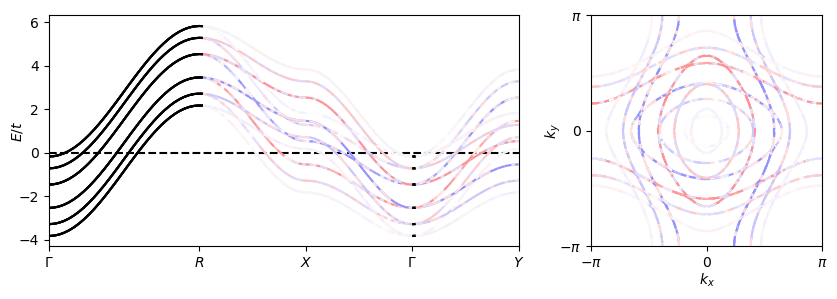

In [5]:
paramS1 = dict(len_z=6,t1=1,t2=0.5,mu=0,m=0.3,t3=0,tz=1,tzp=0,PBC=False,Q_z=pi)

param = paramS1
fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))

#some special points of the brillouin zone

labels = ['\Gamma','R',"X",'\Gamma',"Y"]
pathBZ = np.array([points_BZ[x] for x in labels])
labels = ['$'+l+'$' for l in labels]



coloring_operator = np.kron(np.ones(param['len_z']),Spin_operator) #overall spin_operator
coloring_operator = np.kron(projector2layer(0,len_z=param['len_z']),Spin_operator) #spin operator specific layer
#coloring_operator = np.ones(4*param['len_z']) #no coloring

cmap = cm.get_cmap('bwr')

plot_bandstruc(ax,H_2orb_3D,param=param,points_path=pathBZ,labels_points_path=labels,coloring_operator=coloring_operator,cmap=cmap,N_samples=30)
plot_FS(ax1,H_2orb_3D,param=param,coloring_operator=coloring_operator,cmap=cmap,Lq=50)





/Users/valentin/Documents/1_Promotion/Altermagnetism/Surface/alter_surf/src/blochK/plotting.py:94: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. In future versions, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = copy.copy(mpl.cm.get_cmap("bwr"))
  cmap.set_under(color='black')
/Users/valentin/Documents/1_Promotion/Altermagnetism/Surface/alter_surf/src/blochK/plotting.py:95: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. In future versions, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = copy.copy(mpl.cm.get_cmap("bwr"))
  cmap.set_over(color='gray')
/Users/valentin/Documents/1_Promotion/Altermagnetism/Surface/alter_surf/src/blochK/plotting.py:25: MatplotlibDeprecationWarning: You are modifying the state of a globally r

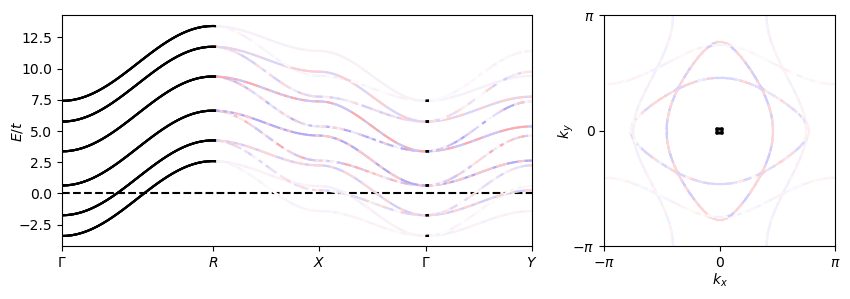

In [6]:
paramS1 = dict(t1=1,t2=0.5,mu=-2,m=0.3,t3=0,tz=3,tzp=0,len_z=6,PBC=False,Q_z=pi)

param = paramS1
fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))

#some special points of the brillouin zone

labels = ['\Gamma','R',"X",'\Gamma',"Y"]
pathBZ = np.array([points_BZ[x] for x in labels])
labels = ['$'+l+'$' for l in labels]



coloring_operator = np.kron(np.ones(param['len_z']),Spin_operator) #overall spin_operator
coloring_operator = np.kron(projector2layer(0,len_z=param['len_z']),Spin_operator) #spin operator specific layer
#coloring_operator = np.ones(4*param['len_z']) #no coloring

cmap = cm.get_cmap('bwr')

plot_bandstruc(ax,H_2orb_3D,param=param,points_path=pathBZ,labels_points_path=labels,coloring_operator=coloring_operator,cmap=cmap,N_samples=30)
plot_FS(ax1,H_2orb_3D,param=param,coloring_operator=coloring_operator,cmap=cmap,Lq=50)





## Plotting the spectral function

In [29]:
Lq = 40 #number of k-points in each direction
Hamiltonian_fct = H_2orb_3D
paramS1 = dict(len_z=40,t1=1,t2=0.5,mu=-3,m=0.6,t3=0,tz=1,tzp=0,PBC=False,Q_z=pi)


# Define the parameters for the Hamiltonian
param = paramS1
# Define the k-point grid
kxs = np.linspace(-pi,pi,Lq)
kys = np.linspace(-pi,pi,Lq)
xs,ys = np.meshgrid(kxs,kys)
ks = np.moveaxis([xs,ys],0,-1)
#Diagonalize Hamiltonian
es,psis = eigs_H(xs,ys,Hamiltonian_fct,param)


def plot_spectral_density(ax,spectral_density,cmap='bwr',title_plot='',show_xlabel=True,show_ylabel=True,vmax='',vmin=''):
    """Plots colored spin spectral density on ax,

    cmap: a matplotlib colormap
    title_plot: title of the plot if given
    vmax: maximum value for color scaling
    """
    if title_plot!='':
         ax.set_title(title_plot,fontsize=6)
    ax.set_aspect('equal')
    if show_xlabel:
        ax.set_xlabel('$k_x$',labelpad=1)
        ax.set_xticks([-pi,0,pi])
        ax.set_xticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_xticklabels([])
    if show_ylabel:
        ax.set_ylabel('$k_y$',labelpad=-2.5)
        ax.set_yticks([-pi,0,pi])
        ax.set_yticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_yticklabels([])
    ax.set_xlim(-pi,pi)
    ax.set_ylim(-pi,pi)
    #--------------
    if vmax == '':
        vmax = np.abs(spectral_density).max()
    if vmin == '':
        vmin = -vmax
    im = ax.imshow(spectral_density,extent=(-pi,pi,-pi,pi),origin='lower',cmap=cmap,vmin=vmin,vmax=vmax)
    return im


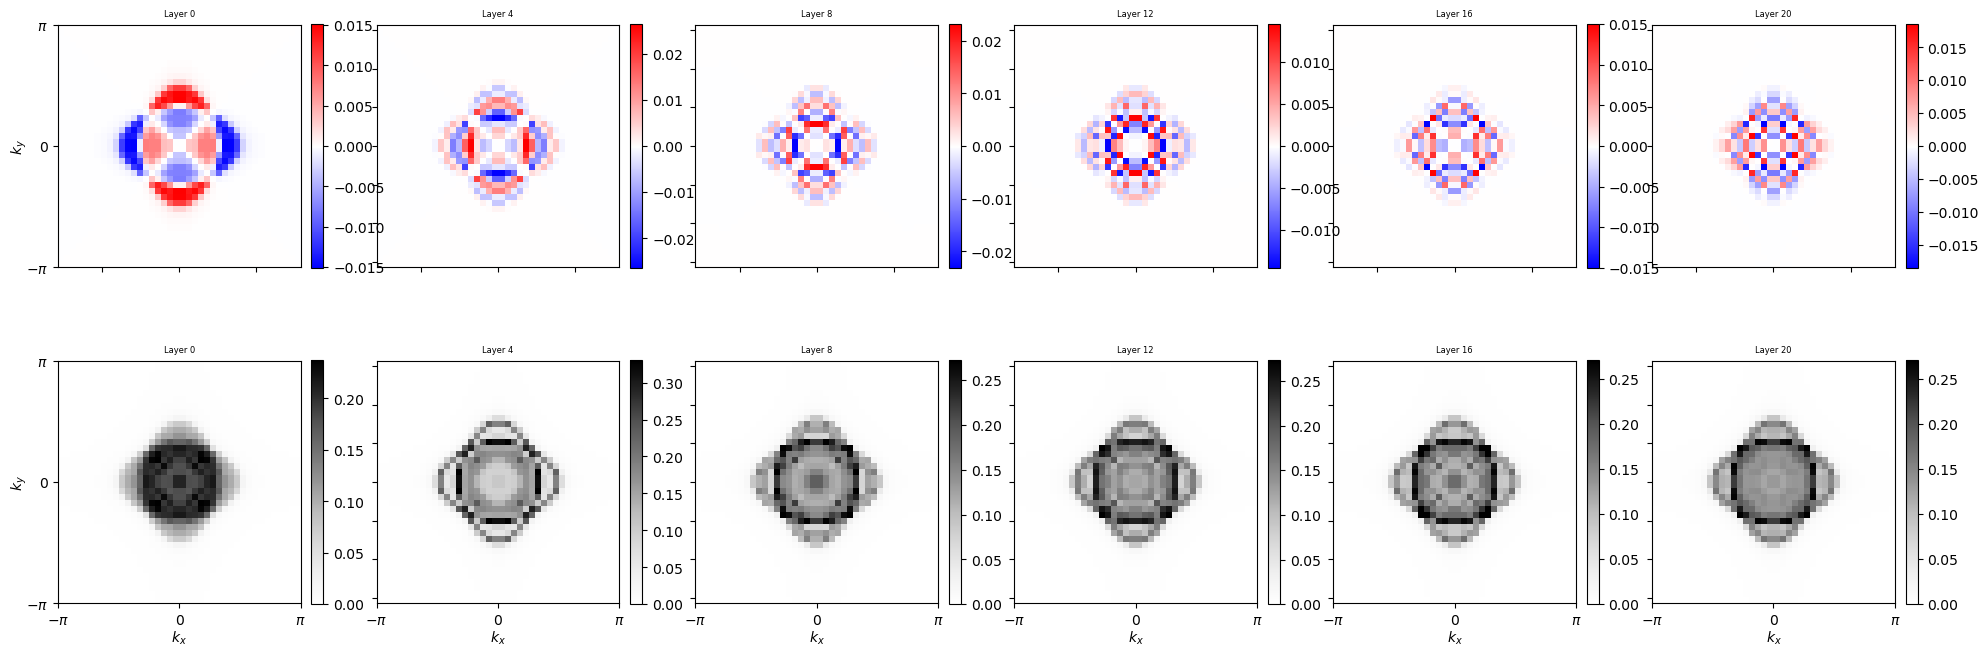

In [ ]:
Gamma = 5e-2
len_z = param['len_z']
#layers = [0,len_z//6,len_z//3,len_z//2]
layers = np.linspace(0,len_z//2,6,dtype=int)


#Plot
fig,axs = plt.subplots(2,len(layers),figsize=(4*len(layers),8))

for ax_column,layer in zip(axs.T,layers):
    proj_2layers = projector2layer(layer,len_z=len_z)+projector2layer(layer+1,len_z=len_z)
    coloring_operator = np.kron(proj_2layers,Spin_operator) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spectral_density_spin = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z

    #compute spectral density
    Os = exp_value_O(np.kron(proj_2layers,np.ones(4)),psis) #.shape=(n,y,x)
    spectral_density0 = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z

    
    vmax_spin = np.abs(spectral_density_spin).max()
    vmax0 = np.abs(spectral_density0).max()

    imT = plot_spectral_density(ax_column[0],spectral_density_spin,title_plot='Layer '+str(layer),show_ylabel=(layer==0),show_xlabel=False,vmax=vmax_spin)
    imB = plot_spectral_density(ax_column[1],spectral_density0,show_ylabel=(layer==0),show_xlabel=True,vmax=vmax0,vmin=0,cmap='Greys')
    
    #colorbars for each plot
    plt.colorbar(imT,ax=ax_column[0],fraction=0.046,pad=0.04)
    plt.colorbar(imB,ax=ax_column[1],fraction=0.046,pad=0.04)    


# plt.colorbar(imT,ax=axs[0,-1],fraction=0.046,pad=0.04)
# plt.colorbar(imB,ax=axs[1,-1],fraction=0.046,pad=0.04)


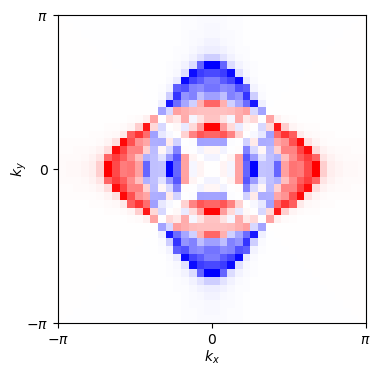

In [28]:
Gamma = 5e-2
coloring_operator = np.kron(projector2layer(len_z//2,len_z=len_z),Spin_operator) #overall spin_operator

#compute spectral density
Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
spectral_density = np.sum(Os/(es**2+Gamma**2),axis=0)/len_z

#Plot
fig,ax = plt.subplots(1,1,figsize=(4,4))
ax.set_aspect('equal')
ax.set_xlabel('$k_x$',labelpad=1)
ax.set_xticks([-pi,0,pi])
ax.set_xticklabels(['$-\pi$',0,'$\pi$'])
ax.set_ylabel('$k_y$',labelpad=-2.5)
ax.set_yticks([-pi,0,pi])
ax.set_yticklabels(['$-\pi$',0,'$\pi$'])
ax.set_xlim(-pi,pi)
ax.set_ylim(-pi,pi)
#--------------
im = ax.imshow(spectral_density,extent=(-pi,pi,-pi,pi),origin='lower',cmap=cmap,vmin=spectral_density.min(),vmax=spectral_density.max())



## Spin conductivity

In [35]:
#setting parameters
Lq = 40 #number of k-points in each direction
Hamiltonian_fct = H_2orb_3D
paramS1 = dict(len_z=40,t1=1,t2=0.5,mu=-3,m=0.6,t3=0,tz=1,tzp=0,PBC=False,Q_z=pi)

param = paramS1

# Calculate spin conductivity
Gamma = 5e-2
kmesh_BZ = sample_BZ(Lq) #you need to work with the right BZ: No translation symmetry breaking -> full BZ
layer = 0
proj_2layers = projector2layer(layer,len_z=param['len_z'])+projector2layer(layer+1,len_z=param['len_z'])
Spin_op_layer = np.kron(proj_2layers,Spin_operator) #projected spin_operator
spin_cond = conductivity(Hamiltonian_fct,Hparam=param,Gamma=Gamma,operator=Spin_op_layer,kmesh_BZ=kmesh_BZ,optimize='path') 
spin_cond

array([[ 1.21277814e-01,  4.88587985e-19],
       [ 8.86157320e-19, -1.21277814e-01]])

In [36]:
layers = layers = np.linspace(0,len_z//2,6,dtype=int)
spin_cond00 = []


for layer in layers:
    proj_2layers = projector2layer(layer,len_z=param['len_z'])+projector2layer(layer+1,len_z=param['len_z'])
    Spin_op_layer = np.kron(proj_2layers,Spin_operator) #projected spin_operator
    spin_cond = conductivity(Hamiltonian_fct,Hparam=param,Gamma=Gamma,operator=Spin_op_layer,kmesh_BZ=kmesh_BZ,optimize='path') 
    spin_cond00.append(spin_cond[0,0])


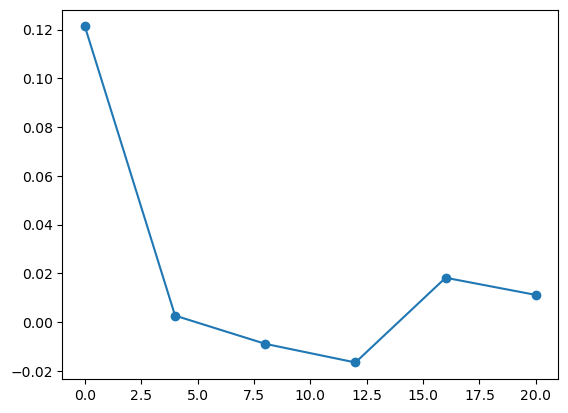

In [37]:
plt.plot(layers,spin_cond00,'o-')

## Checking the spectral density along a 1D path

Let's look at the spectral properties along the path $(0,0)$ to $(\pi,0)$. Then we can see efficiently how spin degneracy is restored

In [100]:
Lq = 200 #number of k-points in each direction
Hamiltonian_fct = H_2orb_3D
paramS1 = dict(len_z=100,t1=1,t2=0.5,mu=-3,m=0.6,t3=0,tz=1,tzp=0,PBC=False,Q_z=pi)
Gamma = 1.5e-1


# Define the parameters for the Hamiltonian
param = paramS1
# Define the k-point grid
kxs = np.linspace(0,pi,Lq)
kys = np.zeros(Lq)
#Diagonalize Hamiltonian
es,psis = eigs_H(kxs,kys,Hamiltonian_fct,param)

#compute spectral density
layers = np.arange(0,param['len_z']//2,1,dtype=int)
spin_spec_dens = []
spec_dens = []
for layer in layers:
    proj_2layers = projector2layer(layer,len_z=param['len_z'])+projector2layer(layer+1,len_z=param['len_z'])
    coloring_operator = np.kron(proj_2layers,Spin_operator) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spin_spec_dens.append(np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/param['len_z'])

    #computespectral density
    Os = exp_value_O(np.kron(proj_2layers,np.ones(4)),psis) #.shape=(n,y,x)
    spec_dens.append(np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/param['len_z'])

spin_spec_dens = np.array(spin_spec_dens)
spec_dens = np.array(spec_dens)


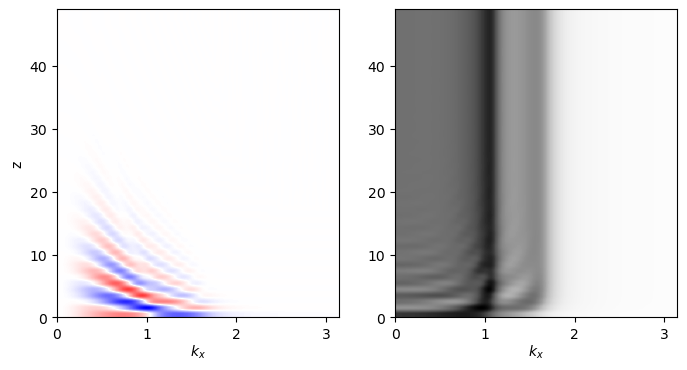

In [101]:
fig,[ax1,ax2] = plt.subplots(1,2,figsize=(8,4))


ax1.set_xlabel('$k_x$',labelpad=1)
ax2.set_xlabel('$k_x$',labelpad=1)
ax1.set_ylabel('z')

vmax = np.abs(spin_spec_dens).max()
im1 = ax1.imshow(spin_spec_dens,extent=(0,pi,0,layers[-1]),origin='lower',cmap='bwr',vmin=-vmax,vmax=vmax,aspect='auto')
im2 = ax2.imshow(spec_dens,extent=(0,pi,0,layers[-1]),origin='lower',cmap='Greys',vmin=0,vmax=spec_dens.max(),aspect='auto')


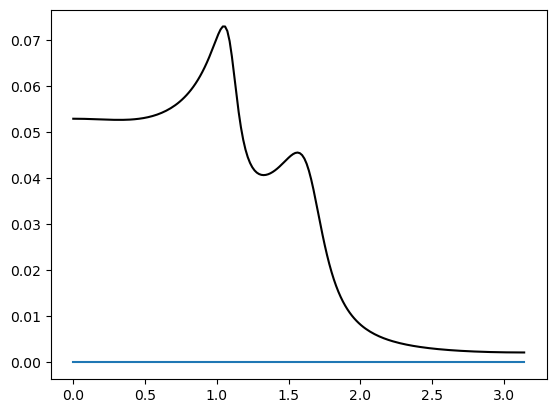

In [102]:
plt.plot(kxs,spin_spec_dens[-1],'-')
plt.plot(kxs,spec_dens[-1],'k-')

Text(0, 0.5, 'integrated spin density')

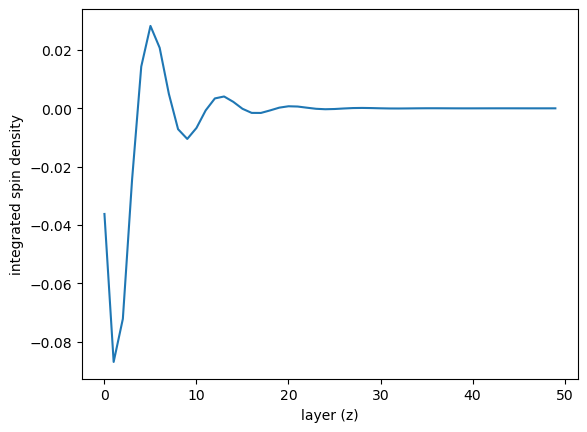

In [103]:
plt.plot(layers,spin_spec_dens.sum(axis=-1))
plt.xlabel('layer (z)')
plt.ylabel('integrated spin density')